# Chaos control and schedule of shuttle buses

A clear, event-driven reimplementation of Nagatani (2006). 

The dimensionless nonlinear map is

$$T_i(m+1)=T_i(m)+\Gamma H_i(m)+\frac{1}{1+S_iH_i(m)},$$

where $H_i(m)$ is measured from the bus that arrived immediately before bus $i$, regardless of bus number. This changing predecessor is the source of the piecewise and chaotic behavior.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from shuttle_model import (
    find_regular_transition,
    simulate,
    summarize,
    theoretical_regular_transition,
    window_observables,
)

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False})

## 1. One simulation

The simulator always processes the earliest pending arrival. It therefore handles overtaking directly, without backward searches or mutable “used” flags.

In [2]:
result = simulate(
    initial_times=(1.0, 2.5),
    gamma=0.2,
    speedups=(0.5, 0.2),
    num_trips=2_000,
)

late_stats = summarize(window_observables(result, start=1_000, stop=2_000))
late_stats

{'H1': {'mean': 0.4383221765420234, 'rms': 0.3100897561528495},
 'DT1': {'mean': 0.9209309651072837, 'rms': 0.04186629984708041},
 'H2': {'mean': 0.6225371748458952, 'rms': 0.3376452554863391},
 'DT2': {'mean': 1.0170912879214422, 'rms': 0.01280468297229294}}

## 2. Reusable parameter sweep

Each value of $\Gamma$ is simulated once. Headways, tour times, means, and RMS fluctuations are then reused by all plots.

In [3]:
INITIAL_TIMES = (1.0, 2.5)
NUM_TRIPS = 1_000
BURN_IN = 900


def sweep(gammas, speedups, num_trips=NUM_TRIPS, burn_in=BURN_IN):
    """Simulate a grid and retain late-time observables and summaries."""
    records = []
    for gamma in np.asarray(gammas):
        simulation = simulate(INITIAL_TIMES, gamma, speedups, num_trips)
        values = window_observables(simulation, burn_in, num_trips)
        records.append({
            "gamma": gamma,
            "values": values,
            "stats": summarize(values),
            "diverged": simulation.diverged,
        })
    return records


def scatter_observable(ax, records, name, size=1.0):
    for record in records:
        values = record["values"][name]
        finite = values[np.isfinite(values)]
        ax.scatter(np.full(finite.size, record["gamma"]), finite, s=size, c="black")
    ax.set_xlabel(r"Loading parameter $\Gamma$")
    ax.set_ylabel(name)

## 3. Headway bifurcation diagrams — paper Figs. 2 and 3

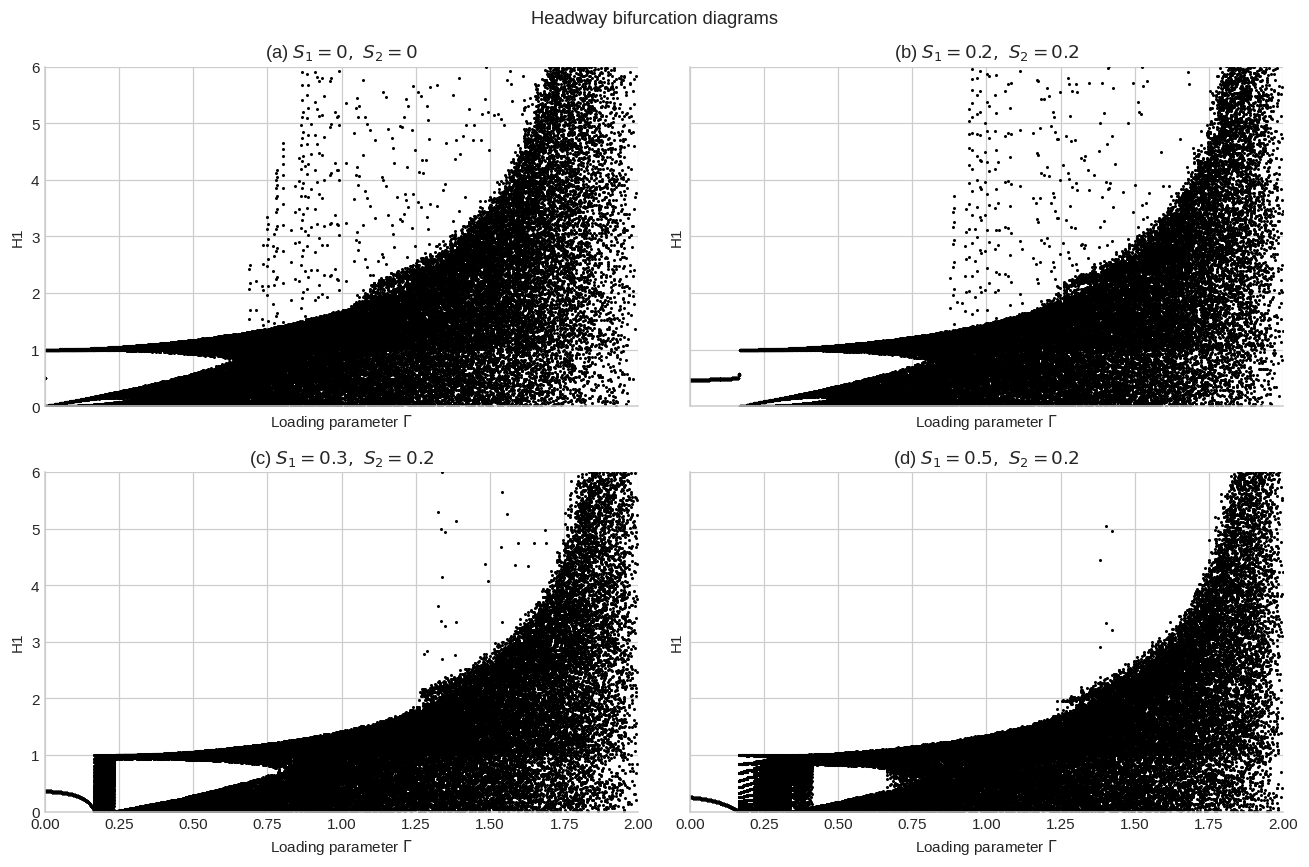

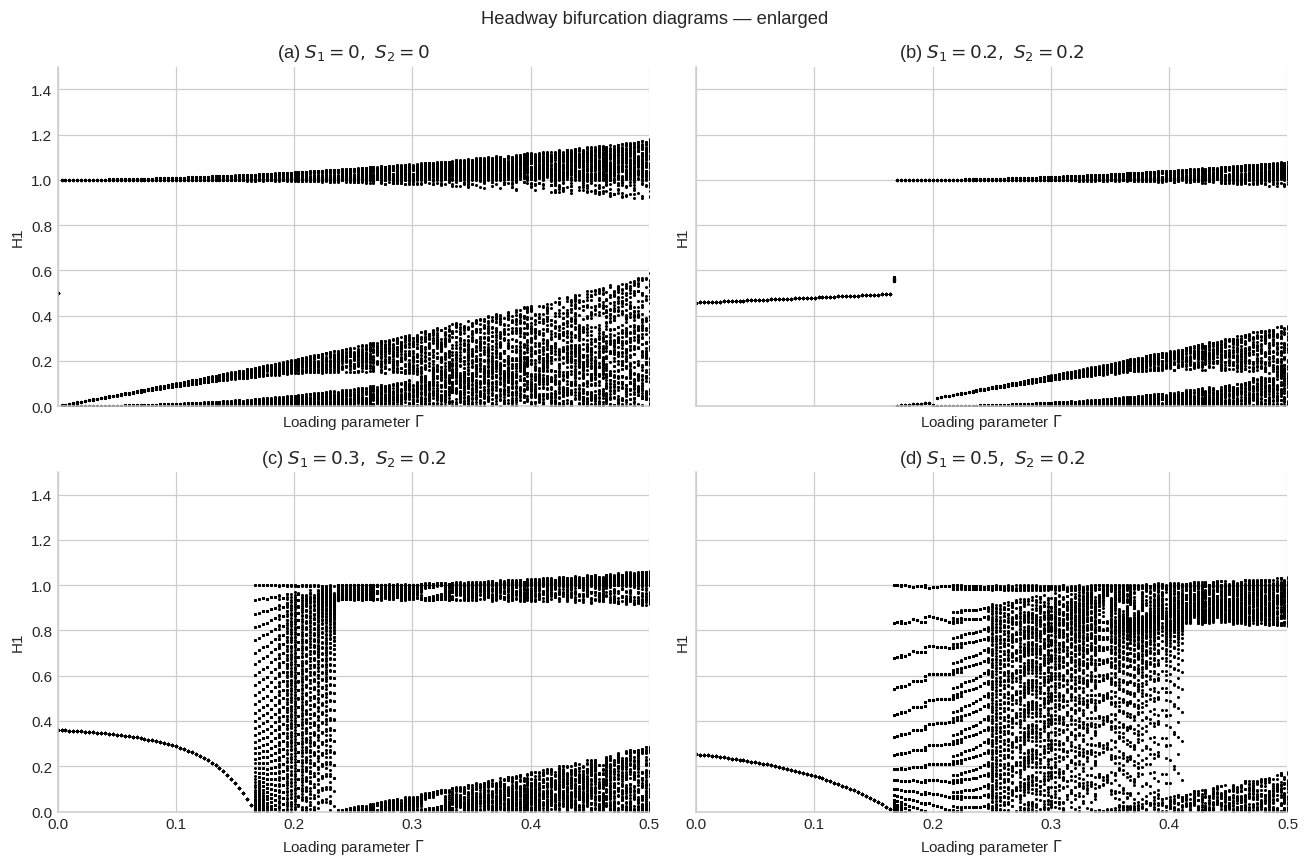

In [4]:
gammas = np.linspace(0.0, 2.0, 600)
configurations = [
    ((0.0, 0.0), r"(a) $S_1=0,\ S_2=0$"),
    ((0.2, 0.2), r"(b) $S_1=0.2,\ S_2=0.2$"),
    ((0.3, 0.2), r"(c) $S_1=0.3,\ S_2=0.2$"),
    ((0.5, 0.2), r"(d) $S_1=0.5,\ S_2=0.2$"),
]
headway_sweeps = {speedups: sweep(gammas, speedups) for speedups, _ in configurations}

fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True, sharey=True)
for ax, (speedups, title) in zip(axes.flat, configurations):
    scatter_observable(ax, headway_sweeps[speedups], "H1")
    ax.set_title(title)
    ax.set_xlim(0, 2)
    ax.set_ylim(0, 6)
fig.suptitle("Headway bifurcation diagrams")
fig.tight_layout()
plt.show()

fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True, sharey=True)
for ax, (speedups, title) in zip(axes.flat, configurations):
    scatter_observable(ax, headway_sweeps[speedups], "H1")
    ax.set_title(title)
    ax.set_xlim(0, 0.5)
    ax.set_ylim(0, 1.5)
fig.suptitle("Headway bifurcation diagrams — enlarged")
fig.tight_layout()
plt.show()

## 4. Tour-time bifurcation diagrams — paper Figs. 4 and 5

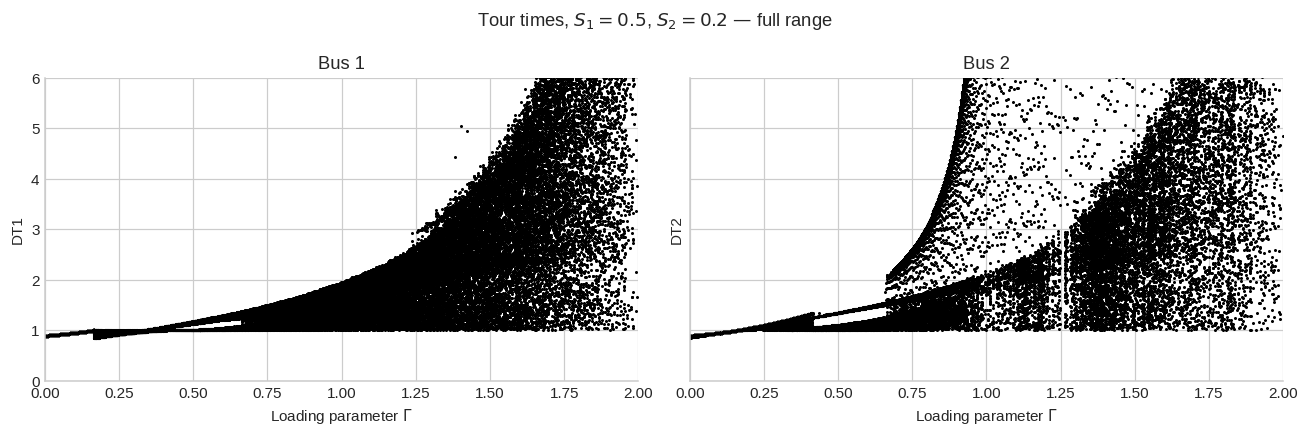

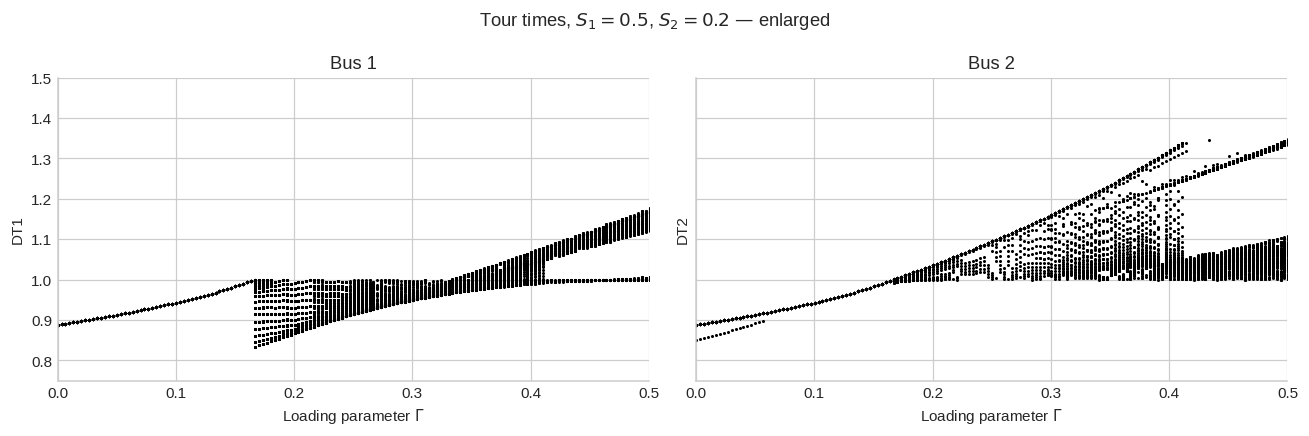

In [5]:
unequal_sweep = headway_sweeps[(0.5, 0.2)]

for xlim, ylim, subtitle in [
    ((0, 2), (0, 6), "full range"),
    ((0, 0.5), (0.75, 1.5), "enlarged"),
]:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharex=True, sharey=True)
    for bus, ax in enumerate(axes, start=1):
        scatter_observable(ax, unequal_sweep, f"DT{bus}")
        ax.set_title(f"Bus {bus}")
        ax.set_xlim(*xlim)
        ax.set_ylim(*ylim)
    fig.suptitle(rf"Tour times, $S_1=0.5$, $S_2=0.2$ — {subtitle}")
    fig.tight_layout()
    plt.show()

## 5. Return maps — paper Fig. 6

The pairs below are successive headways of bus 1: $(H_1(m), H_1(m+1))$. At $\Gamma=0.2$ the 11 distinct points recover the period-11 orbit reported in the paper.

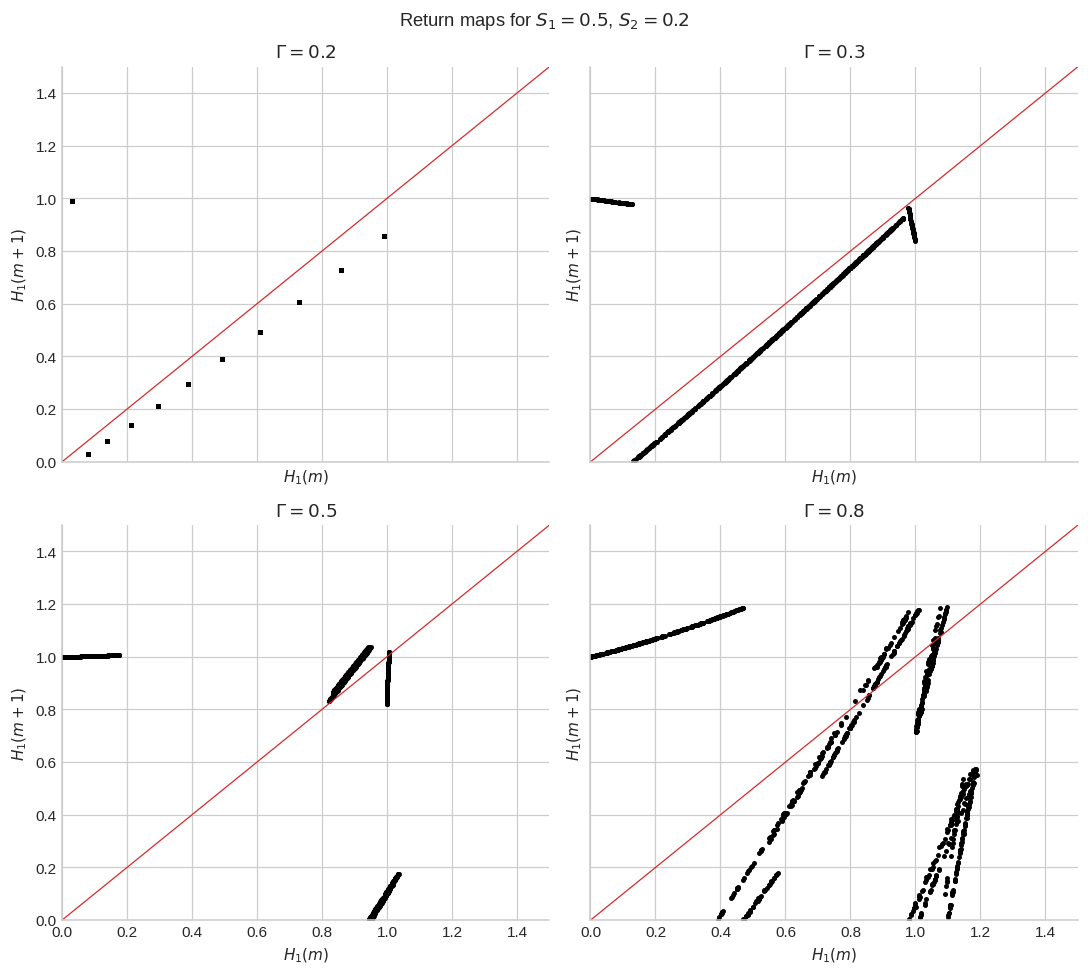

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(10, 9), sharex=True, sharey=True)
for ax, gamma in zip(axes.flat, (0.2, 0.3, 0.5, 0.8)):
    simulation = simulate(INITIAL_TIMES, gamma, (0.5, 0.2), num_trips=2_000)
    h1 = simulation.headways_for(0, start=1_000, stop=2_000)
    ax.scatter(h1[:-1], h1[1:], s=5, c="black")
    ax.plot((0, 1.5), (0, 1.5), color="tab:red", linewidth=0.8)
    ax.set_title(rf"$\Gamma={gamma}$")
    ax.set_xlabel(r"$H_1(m)$")
    ax.set_ylabel(r"$H_1(m+1)$")
    ax.set_xlim(0, 1.5)
    ax.set_ylim(0, 1.5)
fig.suptitle(r"Return maps for $S_1=0.5$, $S_2=0.2$")
fig.tight_layout()
plt.show()

## 6. Means and RMS fluctuations — paper Fig. 7

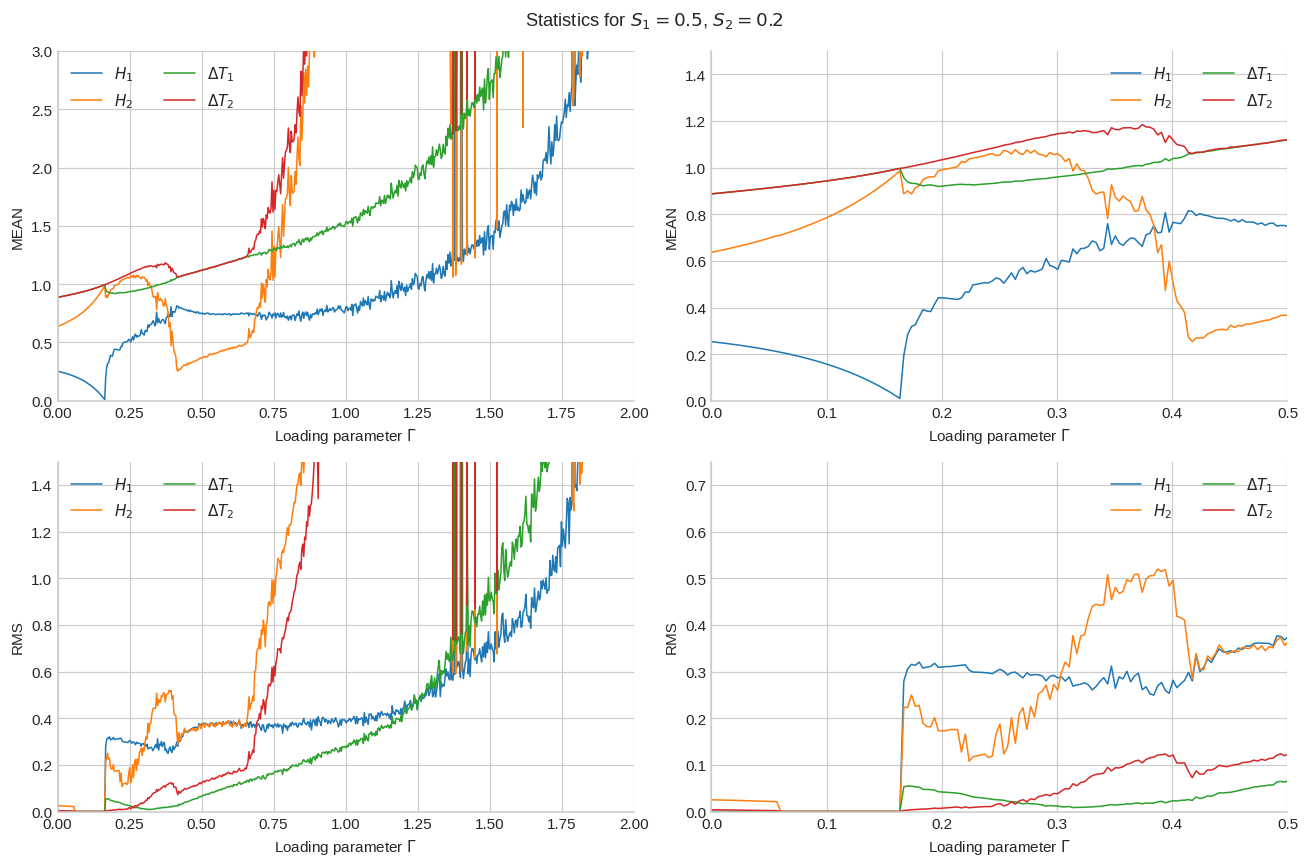

In [7]:
names = ("H1", "H2", "DT1", "DT2")
labels = {"H1": r"$H_1$", "H2": r"$H_2$", "DT1": r"$\Delta T_1$", "DT2": r"$\Delta T_2$"}
gamma_values = np.array([record["gamma"] for record in unequal_sweep])

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for row, metric in enumerate(("mean", "rms")):
    for column, xlim in enumerate(((0, 2), (0, 0.5))):
        ax = axes[row, column]
        for name in names:
            y = np.array([record["stats"][name][metric] for record in unequal_sweep])
            ax.plot(gamma_values, y, linewidth=1, label=labels[name])
        ax.set_xlim(*xlim)
        ax.set_xlabel(r"Loading parameter $\Gamma$")
        ax.set_ylabel(metric.upper())
        ax.legend(ncol=2)
axes[0, 0].set_ylim(0, 3)
axes[0, 1].set_ylim(0, 1.5)
axes[1, 0].set_ylim(0, 1.5)
axes[1, 1].set_ylim(0, 0.75)
fig.suptitle(r"Statistics for $S_1=0.5$, $S_2=0.2$")
fig.tight_layout()
plt.show()

## 7. Phase boundary — paper Fig. 8

For equal speedups, the regular branch has the analytical boundary

$$\Gamma_c=\frac{S}{1+S}.$$

Simulation points use late-time RMS fluctuation and bisection. Near the boundary, convergence is slow, so small numerical offsets are expected for finite runs.

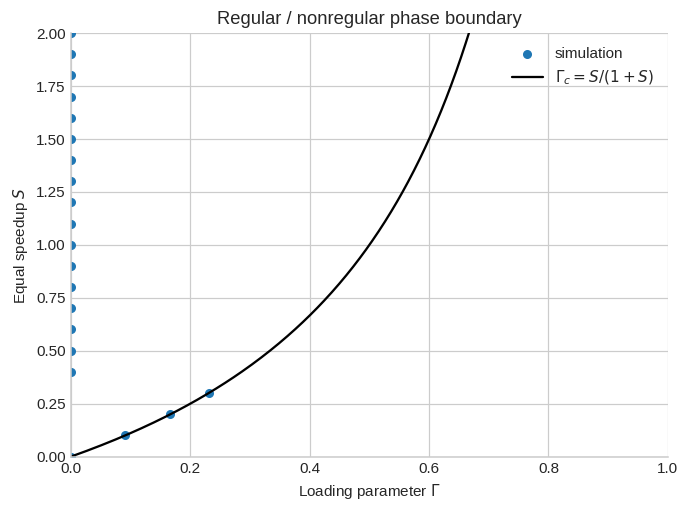

In [8]:
speedup_values = np.linspace(0.0, 2.0, 21)
simulated_boundary = np.array([
    find_regular_transition(
        speedup,
        gamma_max=1.0,
        coarse_points=40,
        bisection_steps=12,
        num_trips=2_000,
        burn_in=1_500,
        tolerance=1e-4,
    )
    for speedup in speedup_values
])

smooth_speedups = np.linspace(0.0, 2.0, 300)
plt.figure(figsize=(7, 5))
plt.scatter(simulated_boundary, speedup_values, s=24, label="simulation")
plt.plot(theoretical_regular_transition(smooth_speedups), smooth_speedups,
         color="black", label=r"$\Gamma_c=S/(1+S)$")
plt.xlabel(r"Loading parameter $\Gamma$")
plt.ylabel(r"Equal speedup $S$")
plt.xlim(0, 1)
plt.ylim(0, 2)
plt.title("Regular / nonregular phase boundary")
plt.legend()
plt.show()

## Interpretation

- Larger $\Gamma$ strengthens the positive feedback from long headways to loading delay.
- Larger $S_i$ shortens the travel portion of the tour and can suppress that feedback.
- Overtaking changes which arrival supplies the headway, making the effective map piecewise.
- Equal speedup produces a clean regularity boundary; unequal speedups create richer period-adding and chaotic regimes.

See `explaination.md` for the complete derivation and implementation notes.